# Per phase equivalent

Laods can be connected in Y- or $\Delta$-connection. Balanced loads are often connected in $\Delta$

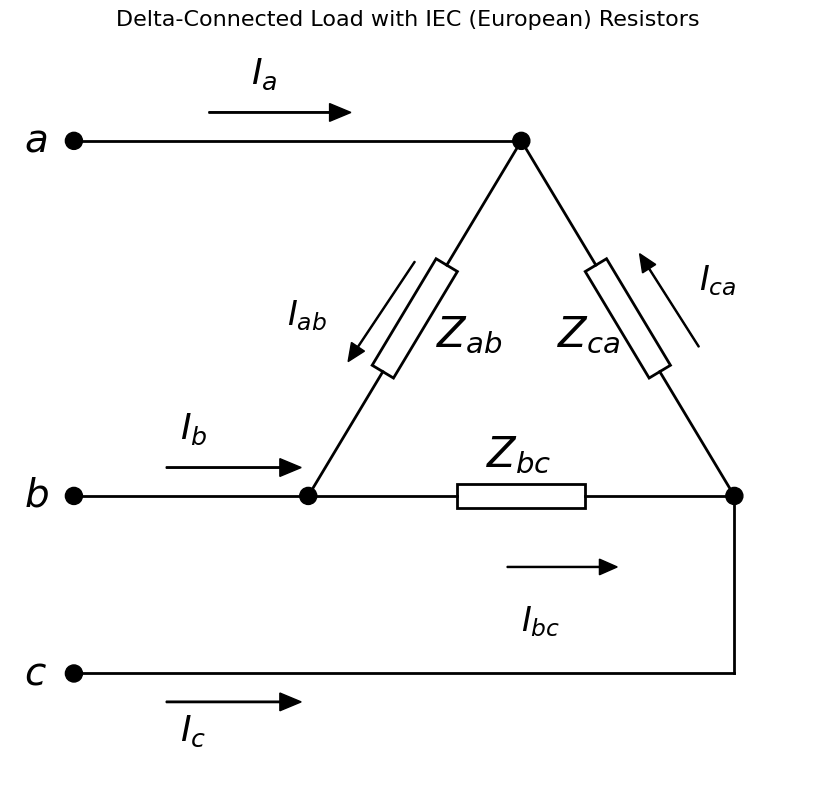

In [11]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.transforms import Affine2D


def draw_european_resistor(ax, p1, p2, width=0.35, length_ratio=0.30):
    x1, y1 = p1
    x2, y2 = p2

    dx = x2 - x1
    dy = y2 - y1
    L = np.hypot(dx, dy)

    ux = dx / L
    uy = dy / L

    lead = (1 - length_ratio) * L / 2

    start = (x1 + ux * lead, y1 + uy * lead)
    end = (x2 - ux * lead, y2 - uy * lead)

    ax.plot([x1, start[0]], [y1, start[1]], 'k', lw=2)
    ax.plot([end[0], x2], [end[1], y2], 'k', lw=2)

    angle = np.degrees(np.arctan2(dy, dx))

    rect = Rectangle(
        (-length_ratio * L / 2, -width / 2),
        length_ratio * L,
        width,
        fill=False,
        linewidth=2,
        edgecolor='black'
    )

    transform = (
        Affine2D()
        .rotate_deg(angle)
        .translate((x1 + x2) / 2, (y1 + y2) / 2)
        + ax.transData
    )

    rect.set_transform(transform)
    ax.add_patch(rect)


fig, ax = plt.subplots(figsize=(10, 8))

A = (7, 8)
B = (4, 3)
C = (10, 3)

a = (0.7, 8)
b = (0.7, 3)
c = (0.7, 0.5)

# Supply conductors
ax.plot([a[0], A[0]], [a[1], A[1]], 'k', lw=2)
ax.plot([b[0], B[0]], [b[1], B[1]], 'k', lw=2)
ax.plot([c[0], C[0]], [c[1], c[1]], 'k', lw=2)
ax.plot([C[0], C[0]], [c[1], C[1]], 'k', lw=2)

# IEC/European resistor delta load
draw_european_resistor(ax, A, B)
draw_european_resistor(ax, B, C)
draw_european_resistor(ax, C, A)

# Nodes
for p in [a, b, c, A, B, C]:
    ax.add_patch(Circle(p, 0.12, color='black'))

# Labels
ax.text(a[0]-0.7, a[1], r'$a$', fontsize=28, va='center')
ax.text(b[0]-0.7, b[1], r'$b$', fontsize=28, va='center')
ax.text(c[0]-0.7, c[1], r'$c$', fontsize=28, va='center')

# Line currents
ax.arrow(2.6, 8.4, 1.7, 0, width=0.02, head_width=0.25, head_length=0.3, color='black')
ax.text(3.2, 8.8, r'$I_a$', fontsize=26)

ax.arrow(2.0, 3.4, 1.6, 0, width=0.02, head_width=0.25, head_length=0.3, color='black')
ax.text(2.2, 3.8, r'$I_b$', fontsize=26)

ax.arrow(2.0, 0.1, 1.6, 0, width=0.02, head_width=0.25, head_length=0.3, color='black')
ax.text(2.2, -0.45, r'$I_c$', fontsize=26)

# Branch currents
ax.arrow(5.5, 6.3, -0.8, -1.2, width=0.015, head_width=0.22, head_length=0.25, color='black')
ax.text(3.7, 5.4, r'$I_{ab}$', fontsize=24)

ax.arrow(6.8, 2.0, 1.3, 0, width=0.015, head_width=0.22, head_length=0.25, color='black')
ax.text(7.0, 1.1, r'$I_{bc}$', fontsize=24)

ax.arrow(9.5, 5.1, -0.7, 1.1, width=0.015, head_width=0.22, head_length=0.25, color='black')
ax.text(9.5, 5.9, r'$I_{ca}$', fontsize=24)

# Impedance labels
ax.text(5.8, 5.1, r'$Z_{ab}$', fontsize=30)
ax.text(6.5, 3.4, r'$Z_{bc}$', fontsize=30)
ax.text(7.5, 5.1, r'$Z_{ca}$', fontsize=30)

ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-0.2, 11)
ax.set_ylim(-1, 9.5)

plt.title('Delta-Connected Load with IEC (European) Resistors', fontsize=16)
plt.tight_layout()
plt.show()


When analysing balanced 3-phase circuits it is not necessary to work with all 3 phases. We use a simplification of the 3-phases, represented with a per-phase equivalent. The per-phase equivalent consists of the voltage represented by its line-to-neutral potential, the line current, impedance (Y-connected) and a neutral connection of zero impedance. Then solve the circuit by KVL. 

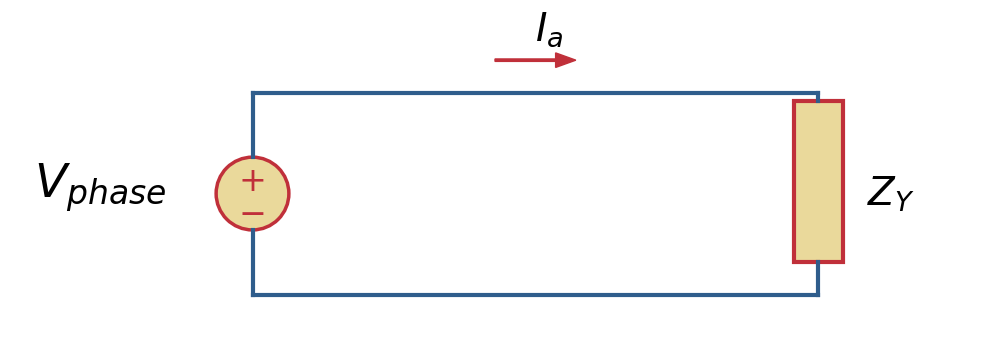

In [17]:
# TEST CELL
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

# Figure
fig, ax = plt.subplots(figsize=(10, 4))

# Colors
wire_color = "#2F5D8C"
comp_color = "#C0303A"
fill_color = "#EAD99B"

# Coordinates
x_left = 3
x_right = 10

y_top = 3
y_bottom = 0.5

# Source
source_y = 1.75
source_r = 0.45

# Load
load_x = 9.7
load_y = 0.9
load_w = 0.6
load_h = 2.0

# Horizontal wires
ax.plot([x_left, x_right], [y_top, y_top], color=wire_color, lw=3)
ax.plot([x_left, x_right], [y_bottom, y_bottom], color=wire_color, lw=3)

# Voltage source leads
ax.plot([x_left, x_left], [y_top, source_y + source_r], color=wire_color, lw=3)
ax.plot([x_left, x_left], [source_y - source_r, y_bottom], color=wire_color, lw=3)

# Voltage source
source = Circle(
    (x_left, source_y),
    source_r,
    facecolor=fill_color,
    edgecolor=comp_color,
    linewidth=2.5
)
ax.add_patch(source)

ax.text(x_left, source_y + 0.15, "+",
        fontsize=24, color=comp_color,
        ha="center", va="center")

ax.text(x_left, source_y - 0.25, "−",
        fontsize=24, color=comp_color,
        ha="center", va="center")

# Load leads
ax.plot([x_right, x_right], [y_top, load_y + load_h], color=wire_color, lw=3)
ax.plot([x_right, x_right], [load_y, y_bottom], color=wire_color, lw=3)

# Load
load = Rectangle(
    (load_x, load_y),
    load_w,
    load_h,
    facecolor=fill_color,
    edgecolor=comp_color,
    linewidth=3
)
ax.add_patch(load)

# Labels
ax.text(
    0.3,
    1.7,
    r"$V_{phase}$",
    fontsize=34
)

ax.text(
    load_x + 0.9,
    source_y,
    r"$Z_Y$",
    fontsize=28,
    va="center"
)

# Current arrow
ax.arrow(
    6.0, 3.4,
    1.0, 0,
    width=0.03,
    head_width=0.18,
    head_length=0.25,
    color=comp_color,
    length_includes_head=True
)

ax.text(
    6.5,
    3.65,
    r"$I_a$",
    fontsize=28
)

# Layout
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()


## Impedance equivalent

It is imperative that the impedance is represented by its Y-connection in a per-phase equivalent. $\Delta$- and Y-connected impedances are equivalent and can be transformed. 

If we have a $\Delta$- connection it can be turned into Y-connection by:

$$Z_Y = \frac{\text{product of adjacent}Z_{\Delta}s}{\text{sum of}Z_{\Delta}} $$

If we have a Y- connection it can be turned into $\Delta$-connection by:

$$Z_{\Delta} = \frac{\text{sum of pairwaise products of}Z_{Y}s}{\text{the opposite}Z_{Y}} $$

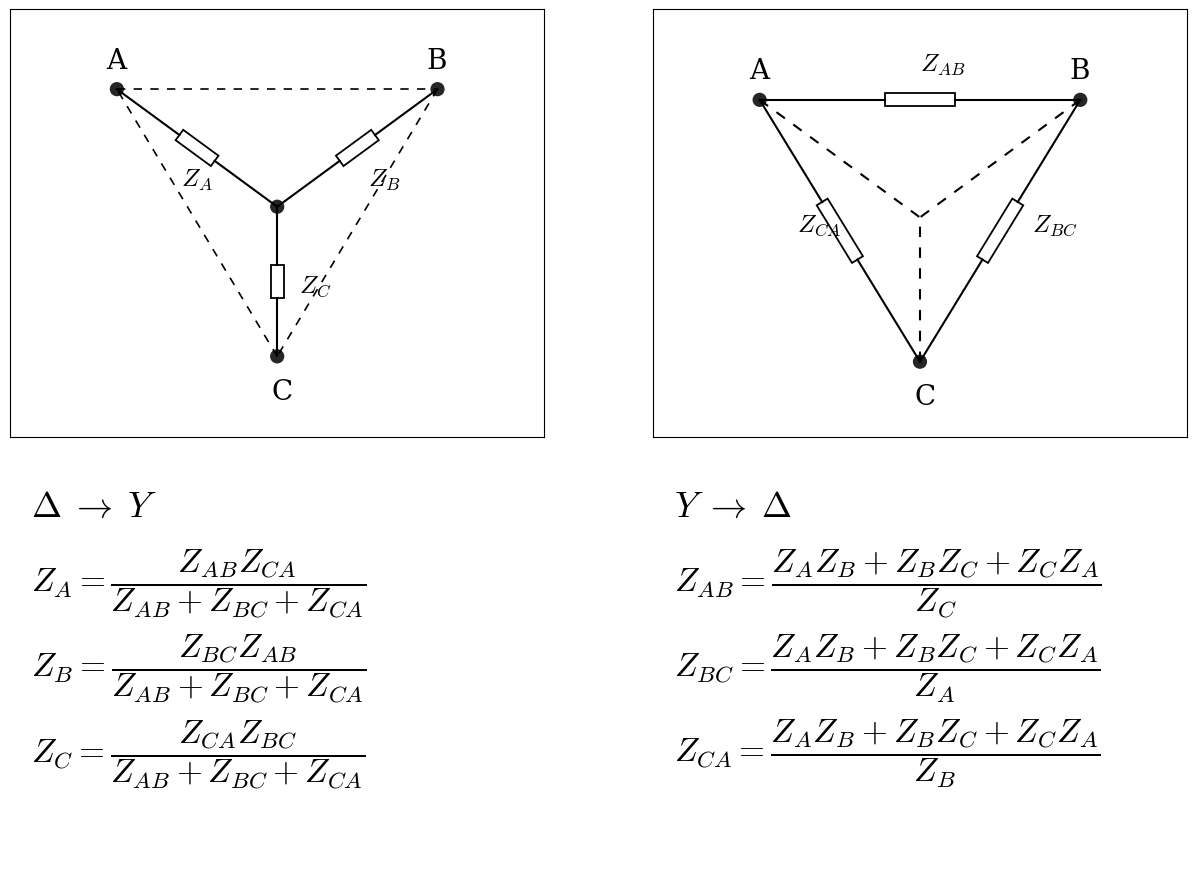

In [18]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.transforms import Affine2D

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"


def draw_resistor(ax, p1, p2, label=None, label_offset=(0, 0)):
    x1, y1 = p1
    x2, y2 = p2

    dx = x2 - x1
    dy = y2 - y1
    length = np.hypot(dx, dy)

    ux = dx / length
    uy = dy / length

    resistor_fraction = 0.22
    resistor_length = resistor_fraction * length
    lead_length = (length - resistor_length) / 2

    start = (x1 + ux * lead_length, y1 + uy * lead_length)
    end = (x2 - ux * lead_length, y2 - uy * lead_length)

    ax.plot([x1, start[0]], [y1, start[1]], 'k', lw=1.5)
    ax.plot([end[0], x2], [end[1], y2], 'k', lw=1.5)

    angle = np.degrees(np.arctan2(dy, dx))

    rect = Rectangle(
        (-resistor_length / 2, -0.12),
        resistor_length,
        0.24,
        fill=False,
        linewidth=1.3
    )

    transform = (
        Affine2D()
        .rotate_deg(angle)
        .translate((x1 + x2) / 2, (y1 + y2) / 2)
        + ax.transData
    )

    rect.set_transform(transform)
    ax.add_patch(rect)

    if label:
        mx = (x1 + x2) / 2 + label_offset[0]
        my = (y1 + y2) / 2 + label_offset[1]
        ax.text(mx, my, label, fontsize=18)


fig, axs = plt.subplots(2, 2, figsize=(14, 9))

for ax in axs.flat:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

# TOP LEFT : DELTA -> Y
ax = axs[0, 0]
A = (2, 6.5)
B = (8, 6.5)
C = (5, 1.5)
N = (5, 4.3)

ax.plot([A[0], B[0]], [A[1], B[1]], 'k--', dashes=(5, 5), lw=1.2)
ax.plot([B[0], C[0]], [B[1], C[1]], 'k--', dashes=(5, 5), lw=1.2)
ax.plot([C[0], A[0]], [C[1], A[1]], 'k--', dashes=(5, 5), lw=1.2)

draw_resistor(ax, A, N, r"$Z_A$", (-0.3, -0.7))
draw_resistor(ax, B, N, r"$Z_B$", (0.2, -0.7))
draw_resistor(ax, C, N, r"$Z_C$", (0.4, -0.2))

for p in [A, B, C, N]:
    ax.add_patch(Circle(p, 0.12, color='0.15'))

ax.text(A[0]-0.2, A[1]+0.4, 'A', fontsize=20)
ax.text(B[0]-0.2, B[1]+0.4, 'B', fontsize=20)
ax.text(C[0]-0.1, C[1]-0.8, 'C', fontsize=20)

# TOP RIGHT : Y -> DELTA
ax = axs[0, 1]
A = (2, 6.3)
B = (8, 6.3)
C = (5, 1.4)
N = (5, 4.1)

ax.plot([A[0], N[0]], [A[1], N[1]], 'k--', dashes=(5, 5))
ax.plot([B[0], N[0]], [B[1], N[1]], 'k--', dashes=(5, 5))
ax.plot([C[0], N[0]], [C[1], N[1]], 'k--', dashes=(5, 5))

draw_resistor(ax, A, B, r"$Z_{AB}$", (0.0, 0.55))
draw_resistor(ax, B, C, r"$Z_{BC}$", (0.6, 0.0))
draw_resistor(ax, C, A, r"$Z_{CA}$", (-0.8, 0.0))

for p in [A, B, C]:
    ax.add_patch(Circle(p, 0.12, color='0.15'))

ax.text(A[0]-0.2, A[1]+0.4, 'A', fontsize=20)
ax.text(B[0]-0.2, B[1]+0.4, 'B', fontsize=20)
ax.text(C[0]-0.1, C[1]-0.8, 'C', fontsize=20)

# BOTTOM LEFT
ax = axs[1, 0]
ax.axis('off')
ax.text(0.4, 6.8, r'$\Delta \;\rightarrow\; Y$', fontsize=26)
ax.text(0.4, 5.4, r'$Z_A=\dfrac{Z_{AB}Z_{CA}}{Z_{AB}+Z_{BC}+Z_{CA}}$', fontsize=24)
ax.text(0.4, 3.8, r'$Z_B=\dfrac{Z_{BC}Z_{AB}}{Z_{AB}+Z_{BC}+Z_{CA}}$', fontsize=24)
ax.text(0.4, 2.2, r'$Z_C=\dfrac{Z_{CA}Z_{BC}}{Z_{AB}+Z_{BC}+Z_{CA}}$', fontsize=24)

# BOTTOM RIGHT
ax = axs[1, 1]
ax.axis('off')
ax.text(0.4, 6.8, r'$Y \;\rightarrow\; \Delta$', fontsize=26)
ax.text(0.4, 5.4, r'$Z_{AB}=\dfrac{Z_AZ_B+Z_BZ_C+Z_CZ_A}{Z_C}$', fontsize=24)
ax.text(0.4, 3.8, r'$Z_{BC}=\dfrac{Z_AZ_B+Z_BZ_C+Z_CZ_A}{Z_A}$', fontsize=24)
ax.text(0.4, 2.2, r'$Z_{CA}=\dfrac{Z_AZ_B+Z_BZ_C+Z_CZ_A}{Z_B}$', fontsize=24)

plt.tight_layout()
plt.show()


### EXAMPLE 2.4
The terminal voltage of a Y-connected load consisting of three equal impedances of $20\angle30^{\circ}\Omega$ is 4.4 kV line to line. The impedance
of each of the three lines connecting the load to a bus at a substation is $Z_L = 1.4\angle75^{\circ}\Omega$.

Find the line-to-line voltage at the substation bus.

Load phase voltage = 2540.3 ∠0° V
Load current = 127.0 ∠-30.0° A
Line voltage drop = 177.8 ∠45.0° V
Substation phase voltage = 2669.0 ∠2.7° V
Substation line-line voltage = 4622.9 ∠32.7° V


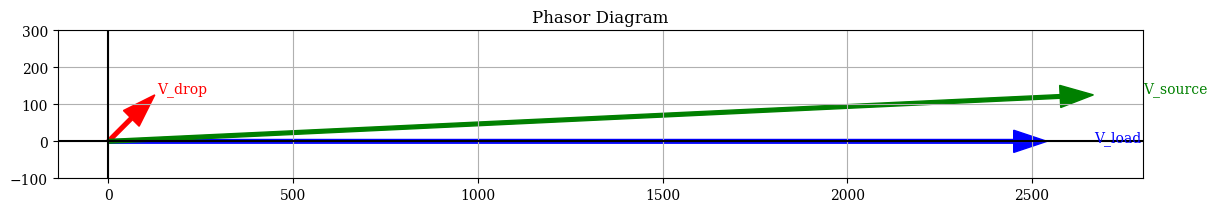

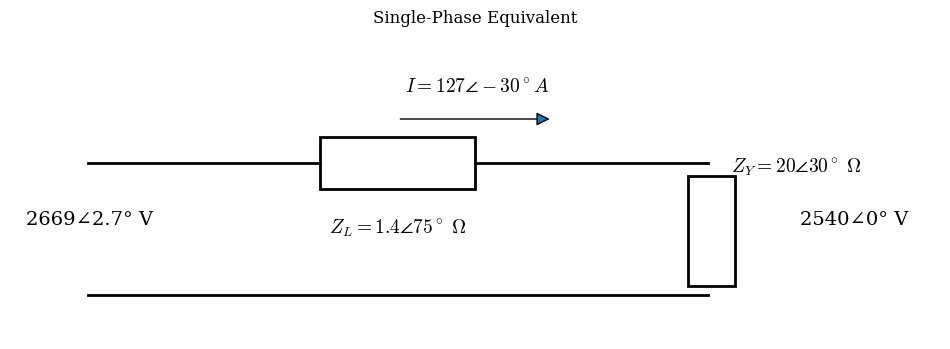

In [50]:
# TEST CELL
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

# variables
VLL_load = 4400
Z_load = cmath.rect(20, math.radians(30))
Z_line = cmath.rect(1.4, math.radians(75))

#load
V_phase_load_mag = VLL_load / math.sqrt(3)
V_phase_load = cmath.rect(V_phase_load_mag, 0)

#Il
I_line = V_phase_load / Z_load

# delta V
V_drop = I_line * Z_line

#V_ln
V_phase_source = V_phase_load + V_drop
V_phase_source_mag = abs(V_phase_source)
V_phase_source_ang = math.degrees(cmath.phase(V_phase_source))

#V_LL
VLL_source_mag = math.sqrt(3) * V_phase_source_mag
VLL_source_ang = V_phase_source_ang + 30

#res
print(f'Load phase voltage = {V_phase_load_mag:.1f} ∠0° V')
print(f'Load current = {abs(I_line):.1f} ∠{math.degrees(cmath.phase(I_line)):.1f}° A')
print(f'Line voltage drop = {abs(V_drop):.1f} ∠{math.degrees(cmath.phase(V_drop)):.1f}° V')
print(f'Substation phase voltage = {V_phase_source_mag:.1f} ∠{V_phase_source_ang:.1f}° V')
print(f'Substation line-line voltage = {VLL_source_mag:.1f} ∠{VLL_source_ang:.1f}° V')

#phasor plot
fig, ax = plt.subplots(figsize=(14,4))

def draw_phasor(z, color, label):
    ax.arrow(0,0,z.real,z.imag,color=color,width=10,
             head_width=60,length_includes_head=True)
    ax.text(z.real*1.05,z.imag*1.05,label,color=color)


draw_phasor(V_phase_load,'blue','V_load')
draw_phasor(V_drop,'red','V_drop')
draw_phasor(V_phase_source,'green','V_source')

ax.axhline(0,color='black')
ax.axvline(0,color='black')
ax.grid(True)
ax.set_ylim(-100, 300)
ax.set_aspect('equal')
ax.set_title('Phasor Diagram')
plt.show()

#per phase diagram
fig, ax = plt.subplots(figsize=(12,4))
ax.axis('off')

ax.plot([1,4],[2,2],'k',lw=2)
ax.plot([6,9],[2,2],'k',lw=2)
ax.plot([1,9],[0.5,0.5],'k',lw=2)

line_imp = Rectangle((4,1.7),2,0.6,fill=False,linewidth=2)
ax.add_patch(line_imp)

load_imp = Rectangle((8.75,0.6),0.6,1.25,fill=False,linewidth=2)
ax.add_patch(load_imp)

ax.text(5,1.2,r'$Z_L=1.4\angle75^\circ\ \Omega$',ha='center',fontsize=14)
ax.text(9.3,1.9,r'$Z_Y=20\angle30^\circ\ \Omega$',fontsize=14)

arrow = FancyArrowPatch((5,2.5),(7,2.5),arrowstyle='-|>',mutation_scale=20)
ax.add_patch(arrow)

ax.text(5.1,2.8,
        rf'$I={abs(I_line):.0f}\angle{math.degrees(cmath.phase(I_line)):.0f}^\circ A$',
        fontsize=14)

ax.text(0.2,1.3,
        rf'{V_phase_source_mag:.0f}∠{V_phase_source_ang:.1f}° V',fontsize=14)

ax.text(10.2,1.3,
        rf'{V_phase_load_mag:.0f}∠0° V',fontsize=14)

plt.title('Single-Phase Equivalent')
plt.xlim(0,12)
plt.ylim(0,3.5)
plt.show()


## Power in balanced 3-phase circuits

If the magnitude of the voltages to neutral \(V_p\) for a Y-connected load is

$$
|V_p| = |V_{an}| = |V_{bn}| = |V_{cn}|
$$

and if the magnitude of the phase current \(I_p\) for a Y-connected load is

$$
|I_p| = |I_{an}| = |I_{bn}| = |I_{cn}|
$$

the total three-phase power is

$$
P = 3|V_p||I_p|\cos\theta_p
$$

where \(\theta_p\) is the angle by which the phase current \(I_p\) lags the phase voltage \(V_p\).

The magnitudes of line-to-line voltage \(V_L\) and line current \(I_L\) are related by

$$
|V_p| = \frac{|V_L|}{\sqrt{3}}
$$

and

$$
|I_p| = |I_L|
$$

Substituting into the power equation gives

$$
P = \sqrt{3}|V_L||I_L|\cos\theta_p
$$

The total reactive power is

$$
Q = 3|V_p||I_p|\sin\theta_p
$$

or

$$
Q = \sqrt{3}|V_L||I_L|\sin\theta_p
$$

The apparent power is

$$
|S| = \sqrt{P^2 + Q^2}
     = \sqrt{3}|V_L||I_L|
$$

For a \(\Delta\)-connected load,

$$
|V_p| = |V_L|
$$

and

$$
|I_p| = \frac{|I_L|}{\sqrt{3}}
$$

The total three-phase power is

$$
P = 3|V_p||I_p|\cos\theta_p
$$

Substituting the \(\Delta\)-connection relationships gives

$$
P = \sqrt{3}|V_L||I_L|\cos\theta_p
$$

Similarly,

$$
Q = \sqrt{3}|V_L||I_L|\sin\theta_p
$$

and

$$
|S| = \sqrt{3}|V_L||I_L|
$$

Thus, for balanced three-phase systems (whether Y-connected or \(\Delta\)-connected),

$$
P = \sqrt{3}|V_L||I_L|\cos\theta_p
$$

$$
Q = \sqrt{3}|V_L||I_L|\sin\theta_p
$$

$$
|S| = \sqrt{3}|V_L||I_L|
$$
